=== ИЗВЛЕЧЕНИЕ ПРИСТУПНЫХ СЕГМЕНТОВ ===
chb08_02.edf: накоплено 86 сегментов
chb08_05.edf: накоплено 100 сегментов
Всего приступных сегментов: 100

=== ИЗВЛЕЧЕНИЕ НЕПРИСТУПНЫХ СЕГМЕНТОВ ===
chb08_02.edf: добавлено, всего 100 сегментов
Всего неприступных сегментов: 100

=== ГЕНЕРАЦИЯ ВЕЙВЛЕТ-ИЗОБРАЖЕНИЙ ===
Изображения приступов уже существуют.
Изображения без приступов уже существуют.

=== ВИЗУАЛИЗАЦИЯ ПРИМЕРОВ ===


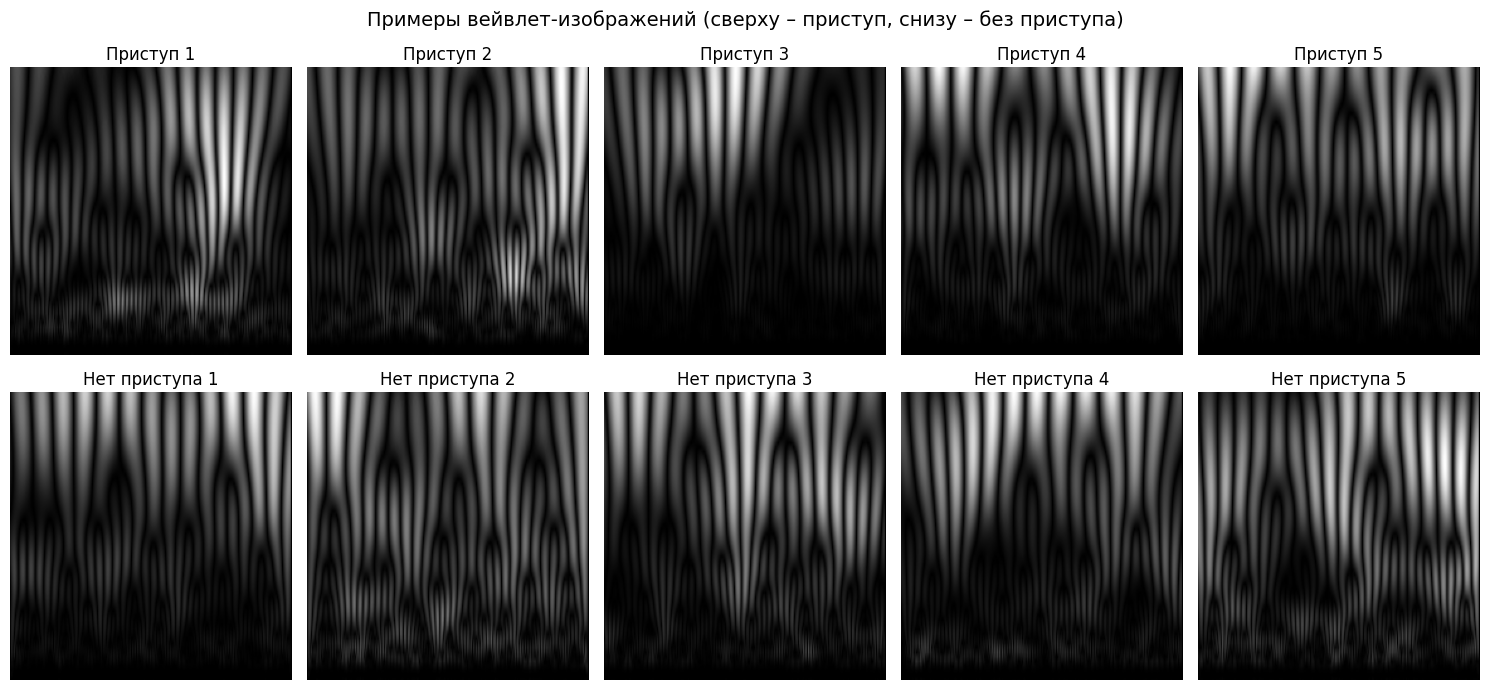

Форма X: (200, 224, 224, 3), классы: [100 100]
Train: 140, Val: 30, Test: 30
Устройство: cuda

=== ОБУЧЕНИЕ ===
Эпоха 10: loss=0.4704, acc=0.8143, val_loss=1.9072, val_acc=0.5000
Эпоха 20: loss=0.3528, acc=0.7857, val_loss=2.5117, val_acc=0.5000
Эпоха 30: loss=0.2633, acc=0.8714, val_loss=0.3034, val_acc=0.8333
Эпоха 40: loss=0.2602, acc=0.8929, val_loss=0.2558, val_acc=0.9000
Эпоха 50: loss=0.2455, acc=0.8714, val_loss=0.4375, val_acc=0.8333
Обучение завершено.


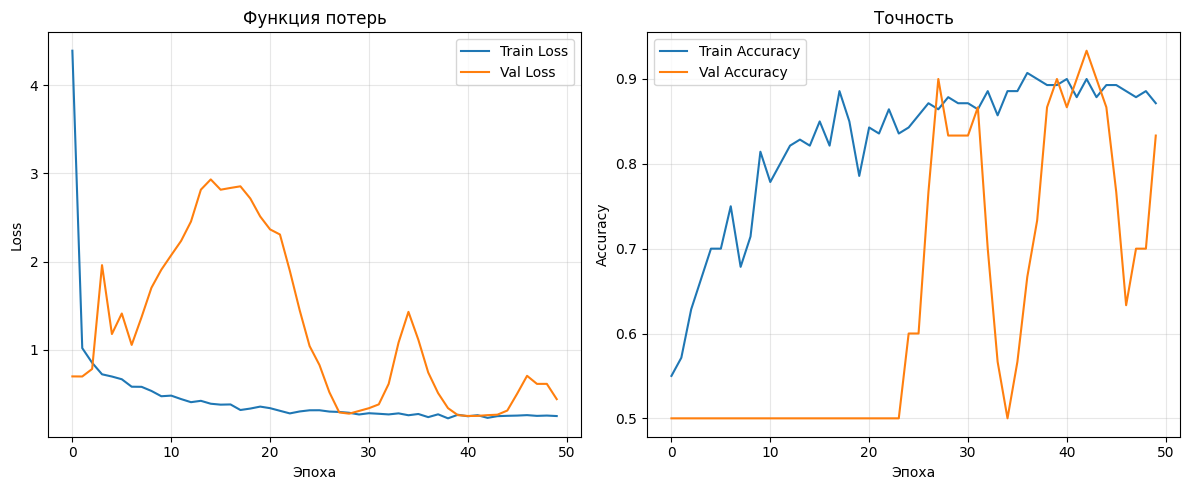


=== РЕЗУЛЬТАТЫ ===
              precision    recall  f1-score   support

Нет приступа       0.89      0.53      0.67        15
     Приступ       0.67      0.93      0.78        15

    accuracy                           0.73        30
   macro avg       0.78      0.73      0.72        30
weighted avg       0.78      0.73      0.72        30

Матрица ошибок:
[[ 8  7]
 [ 1 14]]


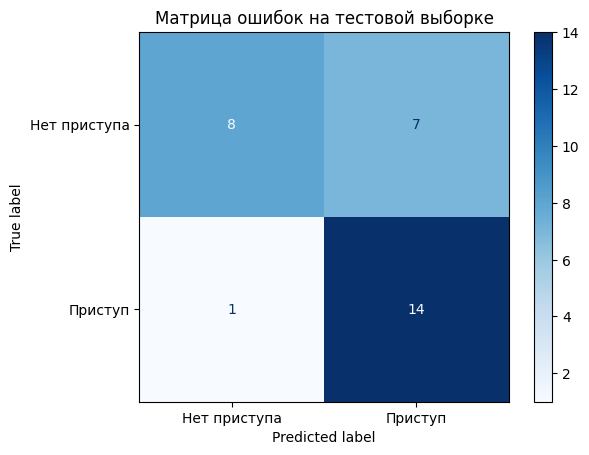

Точность (Accuracy): 0.7333
Precision: 0.6667
Recall: 0.9333
F1-score: 0.7778

Все файлы сохранены (изображения, модель, метрики, графики).


In [15]:
# -*- coding: utf-8 -*-
"""
Классификация ЭЭГ (CHB-MIT, chb08). Вейвлеты + CNN + визуализация.
"""

import os, glob, json
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy import signal
from scipy.ndimage import zoom
import mne
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# -------------------------- КОНФИГУРАЦИЯ --------------------------
DATA_DIR = 'chb08_data'
OUTPUT_DIR = 'eeg_wavelet_output'
SEIZURE_DIR = os.path.join(OUTPUT_DIR, 'seizure')
NON_SEIZURE_DIR = os.path.join(OUTPUT_DIR, 'non_seizure')
PLOTS_DIR = 'plots'
os.makedirs(SEIZURE_DIR, exist_ok=True)
os.makedirs(NON_SEIZURE_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

FS = 256
SEGMENT_DUR = 2
TARGET_SIZE = (224, 224)
N_SEIZURE = 100
N_NON_SEIZURE = 100

SEIZURE_INFO = {
    'chb08_02.edf': [(2670, 2841)],
    'chb08_05.edf': [(2856, 3046)],
    'chb08_11.edf': [(2988, 3122)],
    'chb08_13.edf': [(2417, 2577)],
    'chb08_21.edf': [(2083, 2347)]
}

# ------------------ ФУНКЦИИ ------------------
def preprocess_eeg(raw, fs=FS):
    data, times = raw.get_data(return_times=True)
    avg_data = np.mean(data, axis=0)
    nyq = fs / 2
    b, a = signal.butter(4, 60/nyq, btype='low')
    filtered = signal.filtfilt(b, a, avg_data)
    return filtered, times

def extract_segment(eeg_data, start_sec, duration=SEGMENT_DUR, fs=FS):
    n_samples = int(duration * fs)
    start_idx = int(start_sec * fs)
    end_idx = start_idx + n_samples
    if end_idx > len(eeg_data):
        return None
    return eeg_data[start_idx:end_idx]

def generate_wavelet_image(eeg_segment, fs=FS, output_size=TARGET_SIZE, wavelet='morl'):
    scales = np.arange(1, 65)
    coef, freqs = pywt.cwt(eeg_segment, scales, wavelet, 1/fs)
    cwt_abs = np.abs(coef)
    cwt_norm = (cwt_abs - cwt_abs.min()) / (cwt_abs.max() - cwt_abs.min() + 1e-10)
    cwt_norm = np.flipud(cwt_norm)
    zoom_factors = (output_size[0] / cwt_norm.shape[0], output_size[1] / cwt_norm.shape[1])
    cwt_scaled = zoom(cwt_norm, zoom_factors, order=1)
    cwt_scaled = np.clip(cwt_scaled, 0, 1)
    img = np.stack([cwt_scaled] * 3, axis=-1)
    return (img * 255).astype(np.uint8)

# ------------------ ИЗВЛЕЧЕНИЕ СЕГМЕНТОВ ------------------
print("=== ИЗВЛЕЧЕНИЕ ПРИСТУПНЫХ СЕГМЕНТОВ ===")
seizure_segments = []
for edf_name, intervals in SEIZURE_INFO.items():
    edf_path = os.path.join(DATA_DIR, edf_name)
    if not os.path.exists(edf_path):
        continue
    raw = mne.io.read_raw_edf(edf_path, verbose=False)
    eeg_data, _ = preprocess_eeg(raw)
    for start_sec, end_sec in intervals:
        for t in np.arange(start_sec, end_sec, SEGMENT_DUR):
            if len(seizure_segments) >= N_SEIZURE:
                break
            seg = extract_segment(eeg_data, t)
            if seg is not None:
                seizure_segments.append(seg)
        if len(seizure_segments) >= N_SEIZURE:
            break
    print(f"{edf_name}: накоплено {len(seizure_segments)} сегментов")
    if len(seizure_segments) >= N_SEIZURE:
        break
print(f"Всего приступных сегментов: {len(seizure_segments)}")

print("\n=== ИЗВЛЕЧЕНИЕ НЕПРИСТУПНЫХ СЕГМЕНТОВ ===")
non_seizure_segments = []
np.random.seed(2025)
available_edfs = list(SEIZURE_INFO.keys())
margin = 10

for edf_name in available_edfs:
    edf_path = os.path.join(DATA_DIR, edf_name)
    if not os.path.exists(edf_path):
        continue
    raw = mne.io.read_raw_edf(edf_path, verbose=False)
    eeg_data, times = preprocess_eeg(raw)
    total_dur = times[-1]
    seizure_intervals = SEIZURE_INFO.get(edf_name, [])
    forbidden_zones = [(max(0, s-margin), min(total_dur, e+margin)) for s, e in seizure_intervals]

    possible_starts = []
    for t in np.arange(0, total_dur, SEGMENT_DUR):
        seg_end = t + SEGMENT_DUR
        if seg_end > total_dur:
            continue
        blocked = any(not (seg_end <= f_start or t >= f_end) for f_start, f_end in forbidden_zones)
        if not blocked:
            possible_starts.append(t)

    if not possible_starts:
        continue
    needed = N_NON_SEIZURE - len(non_seizure_segments)
    if needed <= 0:
        break
    chosen = np.random.choice(possible_starts, size=min(needed, len(possible_starts)), replace=False)
    for t in sorted(chosen):
        seg = extract_segment(eeg_data, t)
        if seg is not None:
            non_seizure_segments.append(seg)
    print(f"{edf_name}: добавлено, всего {len(non_seizure_segments)} сегментов")
    if len(non_seizure_segments) >= N_NON_SEIZURE:
        break
print(f"Всего неприступных сегментов: {len(non_seizure_segments)}")

# ------------------ ГЕНЕРАЦИЯ ИЗОБРАЖЕНИЙ (если ещё нет) ------------------
print("\n=== ГЕНЕРАЦИЯ ВЕЙВЛЕТ-ИЗОБРАЖЕНИЙ ===")
if len(glob.glob(os.path.join(SEIZURE_DIR, '*.png'))) < N_SEIZURE:
    for f in glob.glob(os.path.join(SEIZURE_DIR, '*.png')):
        os.remove(f)
    for i, seg in enumerate(seizure_segments):
        img = generate_wavelet_image(seg)
        plt.imsave(os.path.join(SEIZURE_DIR, f'seizure_{i+1:03d}.png'), img)
    print(f"Сохранено {len(seizure_segments)} изображений приступов")
else:
    print("Изображения приступов уже существуют.")

if len(glob.glob(os.path.join(NON_SEIZURE_DIR, '*.png'))) < N_NON_SEIZURE:
    for f in glob.glob(os.path.join(NON_SEIZURE_DIR, '*.png')):
        os.remove(f)
    for i, seg in enumerate(non_seizure_segments):
        img = generate_wavelet_image(seg)
        plt.imsave(os.path.join(NON_SEIZURE_DIR, f'non_seizure_{i+1:03d}.png'), img)
    print(f"Сохранено {len(non_seizure_segments)} изображений без приступов")
else:
    print("Изображения без приступов уже существуют.")

# ------------------ ПРИМЕРЫ ИЗОБРАЖЕНИЙ (для отчёта) ------------------
print("\n=== ВИЗУАЛИЗАЦИЯ ПРИМЕРОВ ===")
seiz_paths = sorted(glob.glob(os.path.join(SEIZURE_DIR, '*.png')))[:5]
non_seiz_paths = sorted(glob.glob(os.path.join(NON_SEIZURE_DIR, '*.png')))[:5]

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for i, path in enumerate(seiz_paths):
    img = plt.imread(path)
    axes[0, i].imshow(img, aspect='auto')
    axes[0, i].set_title(f'Приступ {i+1}')
    axes[0, i].axis('off')
for i, path in enumerate(non_seiz_paths):
    img = plt.imread(path)
    axes[1, i].imshow(img, aspect='auto')
    axes[1, i].set_title(f'Нет приступа {i+1}')
    axes[1, i].axis('off')
fig.suptitle('Примеры вейвлет-изображений (сверху – приступ, снизу – без приступа)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'sample_wavelet_images.png'), dpi=150)
plt.show()

# ------------------ ЗАГРУЗКА ДАННЫХ ------------------
def load_images(folder):
    images = []
    for fpath in sorted(glob.glob(os.path.join(folder, '*.png'))):
        img = plt.imread(fpath)
        if img.ndim == 3 and img.shape[2] == 4:
            img = img[:,:,:3]
        images.append(img)
    return np.array(images)

X_seiz = load_images(SEIZURE_DIR)
X_non = load_images(NON_SEIZURE_DIR)
X = np.concatenate([X_seiz, X_non], axis=0)
y = np.concatenate([np.ones(len(X_seiz)), np.zeros(len(X_non))])
print(f"Форма X: {X.shape}, классы: {np.bincount(y.astype(int))}")

X = X.astype(np.float32) / 255.0

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

def to_torch(X_arr, y_arr):
    X_t = torch.FloatTensor(X_arr).permute(0, 3, 1, 2)
    y_t = torch.FloatTensor(y_arr).unsqueeze(1)
    return X_t, y_t

X_train_t, y_train_t = to_torch(X_train, y_train)
X_val_t, y_val_t = to_torch(X_val, y_val)
X_test_t, y_test_t = to_torch(X_test, y_test)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

# ------------------ CNN МОДЕЛЬ ------------------
class SeizureCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 14 * 14, 256)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 1)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = self.pool(torch.relu(self.bn4(self.conv4(x))))
        x = x.reshape(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SeizureCNN().to(device)
pos_weight = torch.tensor([len(y_train[y_train==0]) / len(y_train[y_train==1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# ------------------ ОБУЧЕНИЕ ------------------
num_epochs = 50
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("\n=== ОБУЧЕНИЕ ===")
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        if np.random.rand() > 0.5:
            batch_X = torch.flip(batch_X, dims=[3])
        if np.random.rand() > 0.5:
            batch_X = torch.clamp(batch_X * np.random.uniform(0.9, 1.1), 0, 1)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_X.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)

    train_loss /= total
    train_acc = correct / total

    model.eval()
    with torch.no_grad():
        val_X, val_y = X_val_t.to(device), y_val_t.to(device)
        val_out = model(val_X)
        val_loss = criterion(val_out, val_y).item()
        val_preds = (torch.sigmoid(val_out) > 0.5).float()
        val_acc = (val_preds == val_y).sum().item() / len(val_y)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')

    if (epoch+1) % 10 == 0:
        print(f"Эпоха {epoch+1:2d}: loss={train_loss:.4f}, acc={train_acc:.4f}, "
              f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

print("Обучение завершено.")

# ------------------ ГРАФИКИ ОБУЧЕНИЯ ------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('Функция потерь')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Accuracy')
axes[1].plot(history['val_acc'], label='Val Accuracy')
axes[1].set_title('Точность')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'training_history.png'), dpi=150)
plt.show()

# ------------------ ОЦЕНКА И МАТРИЦА ОШИБОК ------------------
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
with torch.no_grad():
    test_X, test_y = X_test_t.to(device), y_test_t.to(device)
    y_scores = torch.sigmoid(model(test_X)).cpu().numpy()
    y_pred = (y_scores > 0.5).astype(int).flatten()
    y_true = y_test.astype(int)

print("\n=== РЕЗУЛЬТАТЫ ===")
print(classification_report(y_true, y_pred, target_names=['Нет приступа', 'Приступ']))
cm = confusion_matrix(y_true, y_pred)
print("Матрица ошибок:")
print(cm)

# Heatmap матрицы ошибок
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Нет приступа', 'Приступ'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Матрица ошибок на тестовой выборке')
plt.savefig(os.path.join(PLOTS_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

acc = np.mean(y_pred == y_true)
precision = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
recall = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision+recall) > 0 else 0

print(f"Точность (Accuracy): {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Сохраняем метрики
results = {
    'accuracy': acc,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'confusion_matrix': cm.tolist()
}
with open('evaluation_results.json', 'w') as f:
    json.dump(results, f, indent=2)

torch.save({
    'model_state_dict': model.state_dict(),
    'history': history
}, 'eeg_cnn_model.pth')

print("\nВсе файлы сохранены (изображения, модель, метрики, графики).")